<a href="https://colab.research.google.com/github/rahma3199/Photovoltaic-production-Forecasting-based-Deep-Learning-model/blob/main/interview.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Case Study
### Candidate : Rahma Aloui

## Question 1 — Sampling Analysis  
**Question:** Is the data evenly sampled? If yes, what is its sampling frequency?
### Method
- Compute time differences between consecutive timestamps:
$$
\Delta t_i = t_i - t_{i-1}
$$
- Check if \(\Delta t_i\) is approximately constant  
- Compute the **mean and standard deviation** of \(\Delta t_i\) to verify that the sampling is consistent  
- Estimate sampling frequency:
$$
f_s = \frac{1}{\bar{\Delta t}}
$$
### Why this method?
- The dataset is expected to be **uniformly sampled**, so a simple check is sufficient (no need for complex methods)  
- Time differences directly reveal **sampling regularity**  
- Mean gives a **robust estimate** of the sampling interval  
- Standard deviation verifies that variations are small → confirms **uniform sampling assumption**  
- Simple, robust, and widely used for time-series validation  
### Result
- \(\Delta t \approx 0.1\,\text{s}\)  
- \(f_s \approx 10\,\text{Hz}\)

In [ ]:
# ============================================================
# QUESTION 1 - Sampling Analysis
# Goal:
# Check whether the data is practically evenly sampled
# and estimate the sampling frequency.
# ============================================================
import pandas as pd
import numpy as np
# ------------------------------------------------------------
# 1. Load dataset
# ------------------------------------------------------------
file_path = "Test (1).csv"
df = pd.read_csv(file_path)
print("Dataset loaded successfully")
print("Dataset shape:", df.shape)
print("\nPreview:")
display(df.head(3))
# ------------------------------------------------------------
# 2. Convert timestamp and summarize columns
# ------------------------------------------------------------
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
column_summary = pd.DataFrame({
   "Column": df.columns,
   "Data type": df.dtypes.astype(str),
   "Missing values": df.isna().sum().values
})
print("\nColumn summary:")
display(column_summary)
print("\nTimestamp range:")
print("Start:", df["Timestamp"].min())
print("End  :", df["Timestamp"].max())
# ------------------------------------------------------------
# 3. Compute time differences
# ------------------------------------------------------------
dt_seconds = df["Timestamp"].diff().dropna().dt.total_seconds()
print("\nTime-step statistics in seconds:")
display(dt_seconds.describe().to_frame(name="Value"))
print("\nUnique time steps:")
display(dt_seconds.value_counts().head(10).to_frame(name="Count"))
# ------------------------------------------------------------
# 4. Estimate sampling frequency
# ------------------------------------------------------------
mean_dt = dt_seconds.mean()
fs = 1 / mean_dt
dominant_dt = dt_seconds.mode()[0]
irregular_count = (dt_seconds != dominant_dt).sum()
irregular_ratio = irregular_count / len(dt_seconds)
print("\nEstimated sampling period Δt:", mean_dt, "seconds")
print("Estimated sampling frequency fs:", fs, "Hz")
print("Dominant time step:", dominant_dt, "seconds")
print("Number of irregular intervals:", irregular_count)
print("Irregular interval ratio:", irregular_ratio)
# ------------------------------------------------------------
# 5. Conclusion
# ------------------------------------------------------------
if irregular_ratio < 0.001:
   print("\nConclusion: The data is practically evenly sampled.")
else:
   print("\nConclusion: The data is not evenly sampled.")

Dataset loaded successfully
Dataset shape: (18143997, 3)

Preview:


,Timestamp,Acceleration,Load
0,2020-12-25 00:00:00.165876124,9.395560,10859.135636
1,2020-12-25 00:00:00.265876124,9.410613,11073.020529
2,2020-12-25 00:00:00.365876124,9.446886,11244.556897



Column summary:


,Column,Data type,Missing values
Timestamp,Timestamp,datetime64[ns],0
Acceleration,Acceleration,float64,0
Load,Load,float64,0



Timestamp range:
Start: 2020-12-25 00:00:00.165876124
End  : 2021-01-14 23:59:59.765876124

Time-step statistics in seconds:


,Value
count,1.814400e+07
mean,1.000000e-01
std,2.981118e-11
min,1.000000e-01
25%,1.000000e-01
50%,1.000000e-01
75%,1.000000e-01
max,1.000000e-01



Unique time steps:


,Count
Timestamp,
0.1,18143996



Estimated sampling period Δt: 0.09999999999999626 seconds
Estimated sampling frequency fs: 10.000000000000375 Hz
Dominant time step: 0.1 seconds
Number of irregular intervals: 0
Irregular interval ratio: 0.0

Conclusion: The data is practically evenly sampled.


## Question 2 — Running vs Stopped Detection
**Question:** What is expected of the acceleration signal when the well is turned on as opposed to off? Can we suggest a numerically efficient method to assess the state of the well?
### Physical idea
- When the well is **OFF**, acceleration is nearly constant.
- When the well is **ON**, acceleration becomes **oscillatory** due to rod motion.
### Method
- Compute rolling standard deviation:
$$
\sigma_a(t)=\text{std}(a(t-W:t))
$$
- Use \(W = 10\) seconds, approximately one pump cycle.
- Rolling STD acts as a local motion/activity indicator.
- The distribution of rolling STD is approximately **bimodal**:
 - dense near-zero region → true OFF / shutdown
 - higher-value region → running motion
- Some weak-motion periods lie near the upper tail of the near-zero region.
- Therefore, I use a **histogram-valley threshold**:
 - find the high-count OFF peak near zero
 - locate the first low-count valley after this peak
 - use this valley as the ON/OFF threshold
### Threshold comparison
I compare:
- **Histogram-valley threshold**
- **Mean threshold**
- **Mean + 2 STD threshold**
### Why this method
- Rolling STD captures local signal variability.
- Histogram-valley threshold is data-driven and uses the distribution shape.
- It separates true OFF behavior from weak running better than a global threshold.
- It is simple, efficient, and physically interpretable.
### Result
The final output is a binary signal:
$$
\text{is\_running}(t) \in \{0,1\}
$$
where 1 indicates running and 0 indicates stopped.

In [ ]:
# ============================================================
# QUESTION 2 - Detect running vs stopped from acceleration
# Method: rolling standard deviation + threshold comparison
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
# ------------------------------------------------------------
# 1. Compute rolling standard deviation of acceleration
# ------------------------------------------------------------
window_seconds = 10
window = int(window_seconds * fs)
df["acc_std"] = df["Acceleration"].rolling(window=window).std()
print("Rolling standard deviation computed.")
print("Window size:", window, "samples")
print("Window duration:", window_seconds, "seconds")

Rolling standard deviation computed.
Window size: 100 samples
Window duration: 10 seconds


Rolling standard deviation computed.
Window size: 100 samples
Window duration: 10 seconds


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


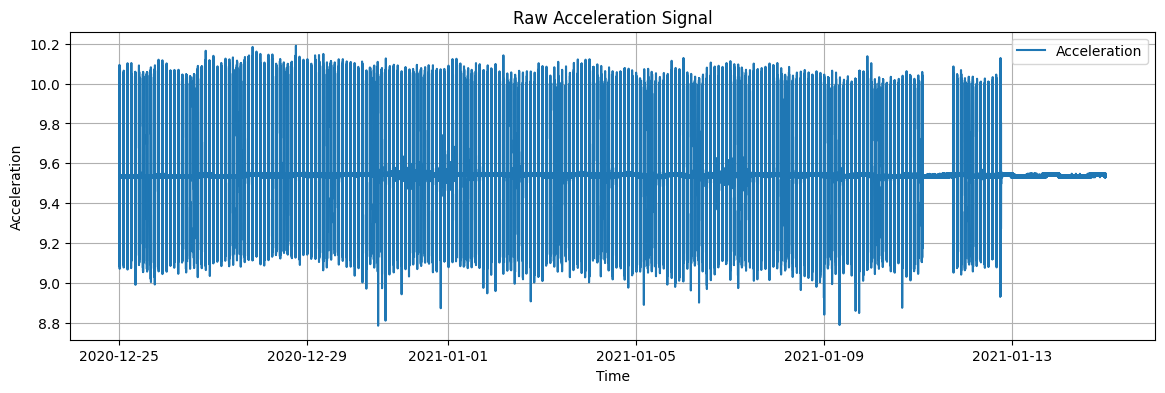

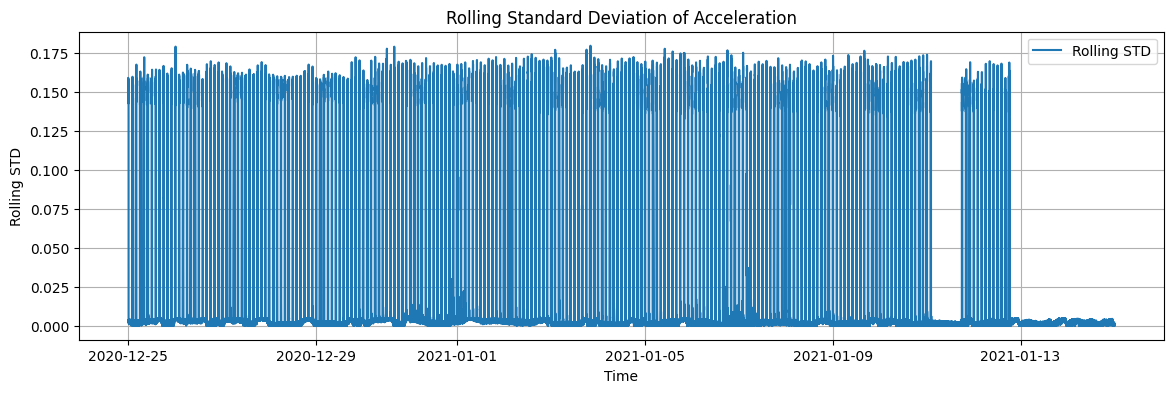

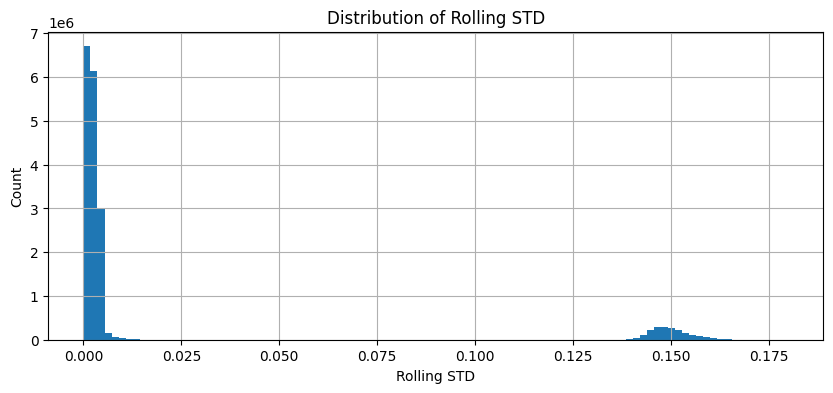

In [ ]:

# ------------------------------------------------------------
# 2. Plot raw acceleration
# ------------------------------------------------------------
plt.figure(figsize=(14, 4))
plt.plot(df["Timestamp"], df["Acceleration"], label="Acceleration")
plt.title("Raw Acceleration Signal")
plt.xlabel("Time")
plt.ylabel("Acceleration")
plt.grid(True)
plt.legend()
plt.show()
# ------------------------------------------------------------
# 3. Plot rolling STD and distribution
# ------------------------------------------------------------
plt.figure(figsize=(14, 4))
plt.plot(df["Timestamp"], df["acc_std"], label="Rolling STD")
plt.title("Rolling Standard Deviation of Acceleration")
plt.xlabel("Time")
plt.ylabel("Rolling STD")
plt.grid(True)
plt.legend()
plt.show()
plt.figure(figsize=(10, 4))
plt.hist(df["acc_std"].dropna(), bins=100)
plt.title("Distribution of Rolling STD")
plt.xlabel("Rolling STD")
plt.ylabel("Count")
plt.grid(True)
plt.show()


OFF peak rolling STD: 0.0004495125529739163
Histogram-valley threshold: 0.005843663188660912


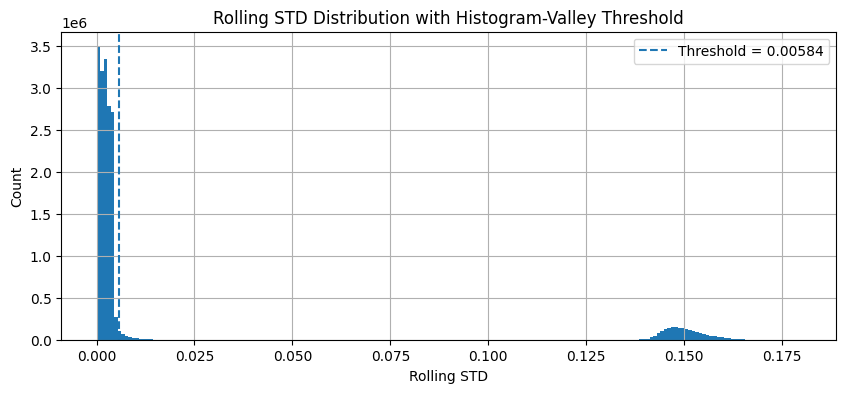

In [ ]:
# ------------------------------------------------------------
# Histogram-valley threshold from rolling STD distribution
# ------------------------------------------------------------
acc_std_clean = df["acc_std"].dropna()
counts, bin_edges = np.histogram(acc_std_clean, bins=200)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
# Find the near-zero OFF peak
off_peak_idx = np.argmax(counts)
# Search for the first low-count valley after the OFF peak
search_counts = counts[off_peak_idx + 1:]
# Define "low count" relative to the OFF peak count
low_count_level = 0.05 * counts[off_peak_idx]  # 5% of OFF peak
valley_candidates = np.where(search_counts < low_count_level)[0]
if len(valley_candidates) > 0:
   valley_idx = off_peak_idx + 1 + valley_candidates[0]
else:
   valley_idx = off_peak_idx + 1 + np.argmin(search_counts)
hist_valley_threshold = bin_centers[valley_idx]
print("OFF peak rolling STD:", bin_centers[off_peak_idx])
print("Histogram-valley threshold:", hist_valley_threshold)
# Plot histogram with selected threshold
plt.figure(figsize=(10, 4))
plt.hist(acc_std_clean, bins=200)
plt.axvline(hist_valley_threshold, linestyle="--", label=f"Threshold = {hist_valley_threshold:.5f}")
plt.title("Rolling STD Distribution with Histogram-Valley Threshold")
plt.xlabel("Rolling STD")
plt.ylabel("Count")
plt.legend()
plt.grid(True)
plt.show()

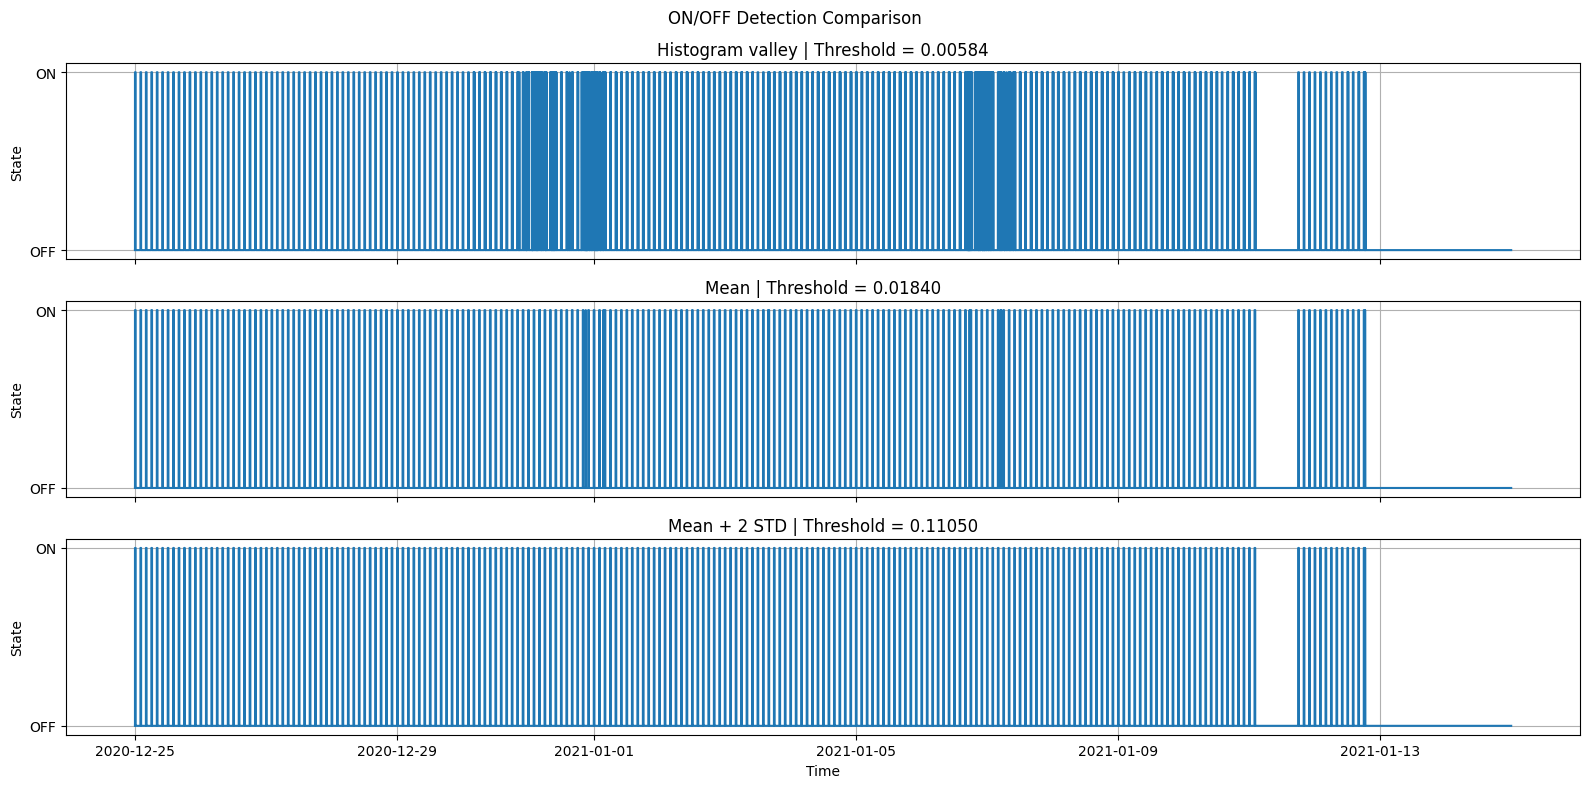

In [ ]:
thresholds = {
   "Histogram valley": hist_valley_threshold,
   "Mean": acc_std_clean.mean(),
   "Mean + 2 STD": acc_std_clean.mean() + 2 * acc_std_clean.std()
}
fig, axes = plt.subplots(3, 1, figsize=(16, 8), sharex=True, sharey=True)
for ax, (name, thr) in zip(axes, thresholds.items()):
   state = (df["acc_std"] > thr).astype(int)
   ax.step(df["Timestamp"], state, where="post")
   ax.set_title(f"{name} | Threshold = {thr:.5f}")
   ax.set_ylabel("State")
   ax.set_yticks([0, 1])
   ax.set_yticklabels(["OFF", "ON"])
   ax.grid(True)
axes[-1].set_xlabel("Time")
plt.suptitle("ON/OFF Detection Comparison")
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
# 6. Select final threshold
# ------------------------------------------------------------
# More sensitive than mean + 2STD, to include low-amplitude running periods.
# You can change this after visual inspection.
selected_threshold_name = "Histogram valley"
threshold = thresholds[selected_threshold_name]
df["is_running"] = (df["acc_std"] > threshold).astype(int)

## Question 3 — Controller Behavior Over Time
**Question:** Can we characterize the well controller settings over time: continuously producing, on timer, or shut down?
### Method / Logic
- Start from the ON/OFF signal obtained in Question 2.
- Divide the signal into consecutive ON and OFF segments.
- Clean the signal by merging very short ON/OFF fragments, since they are likely due to thresholding noise.
- From the initial repeated ON/OFF pattern, learn the normal controller cycle:
 - normal ON duration  
 - normal OFF duration  
- Scan the signal segment by segment and classify:
 - **On timer / cycling:**  
   repeated ON–OFF pattern with durations close to the learned normal ON and OFF durations  
 - **Continuous producing:**  
   ON segments longer than the normal ON duration  
 - **Shutdown:**  
   OFF segments longer than the normal OFF duration  
- Merge adjacent segments with the same label to form continuous blocks.
### Result
The method produces a clear segmentation of the controller behavior over time into:
- On timer / cycling  
- Continuous producing  
- Shutdown

In [ ]:
print("Q3 is using ON/OFF signal from Q2")
print("Selected threshold:", selected_threshold_name)
print("Threshold value:", threshold)

Q3 is using ON/OFF signal from Q2
Selected threshold: Histogram valley
Threshold value: 0.005843663188660912


done
done
Normal ON duration learned from initial cycling part (min): 16.0875
Normal OFF duration learned from initial cycling part (min): 103.9075


,controller_mode,n_blocks,total_duration_hr,mean_duration_min,max_duration_min
0,Continuous producing,2,5.68,170.37,240.00
1,On timer / cycling,4,428.98,6434.67,9960.39
2,Shutdown,2,69.33,2079.92,3218.60


,controller_mode,start,end,n_original_segments,total_duration_sec,duration_min,duration_hr
0,On timer / cycling,2020-12-25 00:00:00.165876124,2020-12-31 22:00:40.065876124,166,597623.4,9960.39,166.01
1,Continuous producing,2020-12-31 22:00:40.165876124,2021-01-01 02:00:40.565876124,6,14399.9,240.00,4.00
2,On timer / cycling,2021-01-01 02:00:40.665876124,2021-01-07 04:20:16.165876124,147,526760.9,8779.35,146.32
3,Continuous producing,2021-01-07 04:20:16.265876124,2021-01-07 06:01:00.565876124,3,6044.1,100.74,1.68
4,On timer / cycling,2021-01-07 06:01:00.665876124,2021-01-11 02:19:18.565876124,93,332288.7,5538.14,92.30
5,Shutdown,2021-01-11 02:19:18.665876124,2021-01-11 18:00:33.265876124,1,56474.6,941.24,15.69
6,On timer / cycling,2021-01-11 18:00:33.365876124,2021-01-12 18:21:23.365876124,25,87647.6,1460.79,24.35
7,Shutdown,2021-01-12 18:21:23.465876124,2021-01-14 23:59:59.765876124,1,193116.3,3218.60,53.64


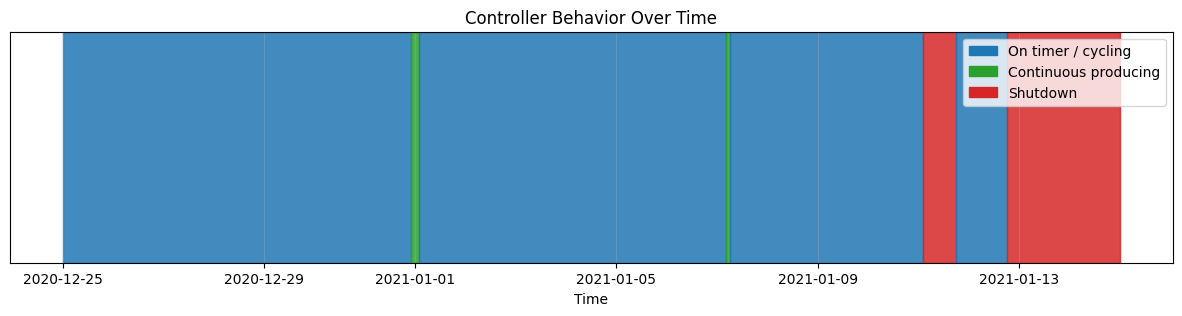

In [ ]:
# ============================================================
# QUESTION 3 - Controller behavior over time
# Robust learned ON/OFF pattern + colored blocks
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
# ------------------------------------------------------------
# 1. Build raw ON/OFF segments from Q2 signal
# ------------------------------------------------------------
work_df = df[["Timestamp", "is_running"]].copy()
def build_segments(signal_col):
   work_df["segment_id"] = (work_df[signal_col].diff() != 0).cumsum()
   seg = (
       work_df.groupby("segment_id")
       .agg(
           state=(signal_col, "first"),
           start=("Timestamp", "first"),
           end=("Timestamp", "last"),
           n_samples=(signal_col, "count")
       )
       .reset_index(drop=True)
   )
   seg["duration_sec"] = (seg["end"] - seg["start"]).dt.total_seconds()
   seg["duration_min"] = seg["duration_sec"] / 60
   seg["state_label"] = seg["state"].map({1: "ON", 0: "OFF"})
   return seg
segments = build_segments("is_running")
print("done")
# ------------------------------------------------------------
# 2. Remove very short fragments by merging them with neighbors
# ------------------------------------------------------------
# ------------------------------------------------------------
# 2. Remove very short fragments at the SEGMENT level
# ------------------------------------------------------------
min_fragment_min = 2
segments["state_clean"] = segments["state"].copy()
for i in range(len(segments)):
   if segments.loc[i, "duration_min"] < min_fragment_min:
       # Prefer merging short fragment with previous segment
       if i > 0:
           segments.loc[i, "state_clean"] = segments.loc[i - 1, "state_clean"]
       # If first segment is short, merge with next segment
       elif i < len(segments) - 1:
           segments.loc[i, "state_clean"] = segments.loc[i + 1, "state"]
# Rebuild cleaned segments directly from segment table
segments["clean_group"] = (
   segments["state_clean"].ne(segments["state_clean"].shift())
).cumsum()
segments = (
   segments.groupby("clean_group")
   .agg(
       state=("state_clean", "first"),
       start=("start", "first"),
       end=("end", "last"),
       n_samples=("n_samples", "sum")
   )
   .reset_index(drop=True)
)
segments["duration_sec"] = (segments["end"] - segments["start"]).dt.total_seconds()
segments["duration_min"] = segments["duration_sec"] / 60
segments["state_label"] = segments["state"].map({1: "ON", 0: "OFF"})
print("done")
# ------------------------------------------------------------
# 3. Learn normal ON/OFF durations from the beginning cycling part
# ------------------------------------------------------------
# Since the plot starts with normal ON/OFF cycling, learn from early valid segments.
valid_segments = segments[segments["duration_min"] >= min_fragment_min].copy()
n_learning_segments = 20
learning_part = valid_segments.head(n_learning_segments)
normal_on_min = learning_part.loc[learning_part["state"] == 1, "duration_min"].median()
normal_off_min = learning_part.loc[learning_part["state"] == 0, "duration_min"].median()

print("Normal ON duration learned from initial cycling part (min):", normal_on_min)
print("Normal OFF duration learned from initial cycling part (min):", normal_off_min)
# ------------------------------------------------------------
# 4. Define normal timing rules
# ------------------------------------------------------------
tolerance = 0.50          # wider tolerance because field data is not perfectly periodic
shutdown_factor = 1.30
continuous_factor = 1.30
segments["is_normal_on"] = (
   (segments["state"] == 1) &
   (segments["duration_min"].between(
       (1 - tolerance) * normal_on_min,
       (1 + tolerance) * normal_on_min
   ))
)
segments["is_normal_off"] = (
   (segments["state"] == 0) &
   (segments["duration_min"].between(
       (1 - tolerance) * normal_off_min,
       (1 + tolerance) * normal_off_min
   ))
)
segments["is_normal_timer_segment"] = segments["is_normal_on"] | segments["is_normal_off"]
# ------------------------------------------------------------
# 5. Classify controller behavior
# ------------------------------------------------------------
segments["controller_mode"] = "Continuous producing"
# Long OFF = shutdown
segments.loc[
   (segments["state"] == 0) &
   (segments["duration_min"] > shutdown_factor * normal_off_min),
   "controller_mode"
] = "Shutdown"
# Long ON remains continuous producing
segments.loc[
   (segments["state"] == 1) &
   (segments["duration_min"] > continuous_factor * normal_on_min),
   "controller_mode"
] = "Continuous producing"
# Timer/cycling = repeated normal alternating segments
min_repeated_segments = 4  # ON-OFF-ON-OFF or OFF-ON-OFF-ON
i = 0
while i < len(segments):
   if segments.loc[i, "controller_mode"] == "Shutdown":
       i += 1
       continue
   if not segments.loc[i, "is_normal_timer_segment"]:
       i += 1
       continue
   start_i = i
   j = i + 1
   while j < len(segments):
       if (
           segments.loc[j, "is_normal_timer_segment"] and
           segments.loc[j, "state"] != segments.loc[j - 1, "state"] and
           segments.loc[j, "controller_mode"] != "Shutdown"
       ):
           j += 1
       else:
           break
   if (j - start_i) >= min_repeated_segments:
       segments.loc[start_i:j-1, "controller_mode"] = "On timer / cycling"
   i = j
# Shutdown dominant
segments.loc[
   (segments["state"] == 0) &
   (segments["duration_min"] > shutdown_factor * normal_off_min),
   "controller_mode"
] = "Shutdown"
# ------------------------------------------------------------
# 6. Merge adjacent segments with same controller mode
# ------------------------------------------------------------
segments["mode_block_id"] = (
   segments["controller_mode"].ne(segments["controller_mode"].shift())
).cumsum()
controller_blocks = (
   segments.groupby("mode_block_id")
   .agg(
       controller_mode=("controller_mode", "first"),
       start=("start", "first"),
       end=("end", "last"),
       n_original_segments=("controller_mode", "count"),
       total_duration_sec=("duration_sec", "sum")
   )
   .reset_index(drop=True)
)
controller_blocks["duration_min"] = controller_blocks["total_duration_sec"] / 60
controller_blocks["duration_hr"] = controller_blocks["total_duration_sec"] / 3600
# ------------------------------------------------------------
# 7. Summary table
# ------------------------------------------------------------
controller_summary = (
   controller_blocks.groupby("controller_mode")
   .agg(
       n_blocks=("controller_mode", "count"),
       total_duration_hr=("duration_hr", "sum"),
       mean_duration_min=("duration_min", "mean"),
       max_duration_min=("duration_min", "max")
   )
   .reset_index()
)
display(controller_summary.round(2))
display(controller_blocks.round(2))
# ------------------------------------------------------------
# 8. Colored block plot
# ------------------------------------------------------------
color_map = {
   "On timer / cycling": "tab:blue",
   "Continuous producing": "tab:green",
   "Shutdown": "tab:red"
}
fig, ax = plt.subplots(figsize=(15, 3))
for _, row in controller_blocks.iterrows():
   ax.axvspan(
       row["start"],
       row["end"],
       color=color_map[row["controller_mode"]],
       alpha=0.85
   )
ax.set_title("Controller Behavior Over Time")
ax.set_xlabel("Time")
ax.set_yticks([])
ax.set_ylim(0, 1)
ax.grid(True, axis="x", alpha=0.3)
legend_patches = [
   mpatches.Patch(color=color_map["On timer / cycling"], label="On timer / cycling"),
   mpatches.Patch(color=color_map["Continuous producing"], label="Continuous producing"),
   mpatches.Patch(color=color_map["Shutdown"], label="Shutdown")
]
ax.legend(handles=legend_patches, loc="upper right")
plt.show()

## Question 4 — Runtime Estimation
### Method
- Use the controller labels from Question 3.
- Exclude periods labeled as **Shutdown**.
- Compute runtime over the remaining considered period.
### Result
Runtime ratio is calculated as:
$$
\text{Runtime Ratio} =
\frac{\text{Running Time}}{\text{Total Considered Time}}
$$
Shutdown periods are removed so they do not bias the runtime estimate.

In [ ]:
# ============================================================
# QUESTION 4 - Runtime estimation
# Uses Q2 ON/OFF signal + Q3 shutdown labels
# ============================================================
# ------------------------------------------------------------
# 1. Mark shutdown samples from Q3 controller blocks
# ------------------------------------------------------------
df_runtime = df[["Timestamp", "is_running"]].copy()
df_runtime["is_shutdown"] = 0
for _, row in controller_blocks.iterrows():
   if row["controller_mode"] == "Shutdown":
       mask = (
           (df_runtime["Timestamp"] >= row["start"]) &
           (df_runtime["Timestamp"] <= row["end"])
       )
       df_runtime.loc[mask, "is_shutdown"] = 1
# ------------------------------------------------------------
# 2. Exclude shutdown samples
# ------------------------------------------------------------
df_considered = df_runtime[df_runtime["is_shutdown"] == 0].copy()
# ------------------------------------------------------------
# 3. Compute runtime ratio
# ------------------------------------------------------------
total_considered_time_sec = len(df_considered) / fs
running_time_sec = df_considered["is_running"].sum() / fs
runtime_ratio = running_time_sec / total_considered_time_sec
runtime_percentage = runtime_ratio * 100
print("Total considered time (s):", round(total_considered_time_sec, 2))
print("Running time (s):", round(running_time_sec, 2))
print("Runtime ratio:", round(runtime_ratio, 4))
print("Runtime percentage:", round(runtime_percentage, 2), "%")
print("Shutdown samples excluded:", df_runtime["is_shutdown"].sum())

Total considered time (s): 1564808.6
Running time (s): 226371.9
Runtime ratio: 0.1447
Runtime percentage: 14.47 %
Shutdown samples excluded: 2495911


## Question 5 — Position Reconstruction Challenges
**Question:** Can position be reconstructed from acceleration alone? What are the possible challenges, and how can we overcome them?
### 1. Can position be reconstructed from acceleration?
Yes, theoretically.
- Velocity is obtained by integration:
$$
v(t)=\int a(t)\,dt
$$
- Position is obtained by double integration:
$$
x(t)=\int\int a(t)\,dt^2
$$
However, the measured signal is:
$$
a_m(t)=a_{\text{motion}}(t)+g+b+n(t)
$$
### 2. Main challenges
- **Constant bias (gravity + sensor offset):** causes strong drift in position (quadratic effect)
- **Noise amplification:** high-frequency noise accumulates during integration
- **Low-frequency drift:** slow variations lead to large position errors over time
### 3. How to overcome these challenges
- **Baseline removal:**
$$
a_0(t)=a_m(t)-\overline{a_m}
$$
- **Band-pass filtering:**
$$
0.05 \leq f \leq 0.1 \text{ Hz}
$$
  - removes low-frequency drift and bias  
  - removes high-frequency noise  
  - keeps pump motion  
- **Detrending after integration:** removes remaining slow drift in velocity and position  


=> with **acceleration only**, filtering + double integration is the most practical approach.

## Question 6 — Position Reconstruction Implementation
**Question:** Implement a method to compute the polished rod position and estimate the stroke amplitude.
### Method
1. **Select time interval**: choose a short, continuous window of data  
2. **Remove baseline**
$$
a_0(t)=a_m(t)-\overline{a_m}
$$
3. **Apply band-pass filter**
$$
0.05 \leq f \leq 0.1 \text{ Hz}
$$
    - isolates pump motion  
    - removes drift and noise  
4. **Integrate acceleration → velocity**
$$
v(t)=\int a_f(t)\,dt
$$
5. **Detrend velocity**: removes integration drift  by fitting a linear function
6. **Integrate velocity → position**
$$
x(t)=\int v(t)\,dt
$$
7. **Detrend and center position** : ensures a stable oscillatory signal  
8. **Trim signal edges**: remove boundary distortions from filtering  
9. **Estimate stroke amplitude**
$$
A_{\text{stroke}}=\max(x)-\min(x)
$$
### Result
- The reconstructed position shows **periodic motion** of the rod  
- After trimming, the signal is stable  
- Stroke amplitude is estimated from the **reliable portion of the signal**

Selected window: 2020-12-25 02:01:00.065876124 to 2020-12-25 02:10:59.965876124
Number of samples: 6000
Baseline removed: 9.514112895156984
Band-pass filter: 0.05 - 0.1 Hz
Estimated stroke amplitude after trimming: 0.6536569160126303


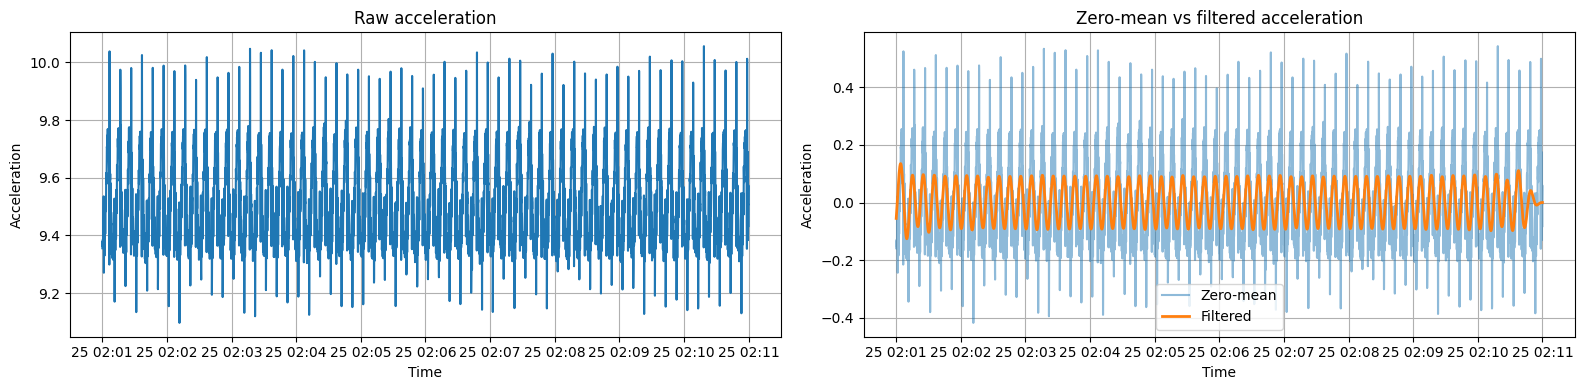

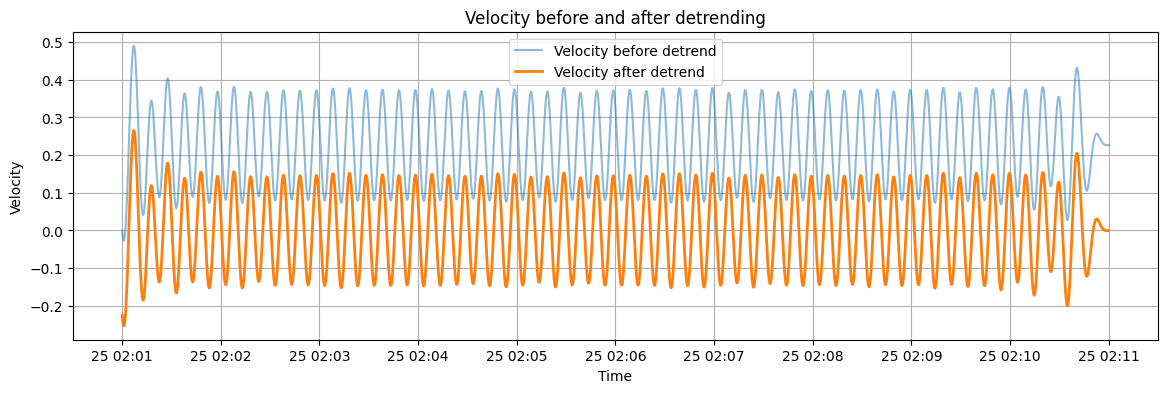

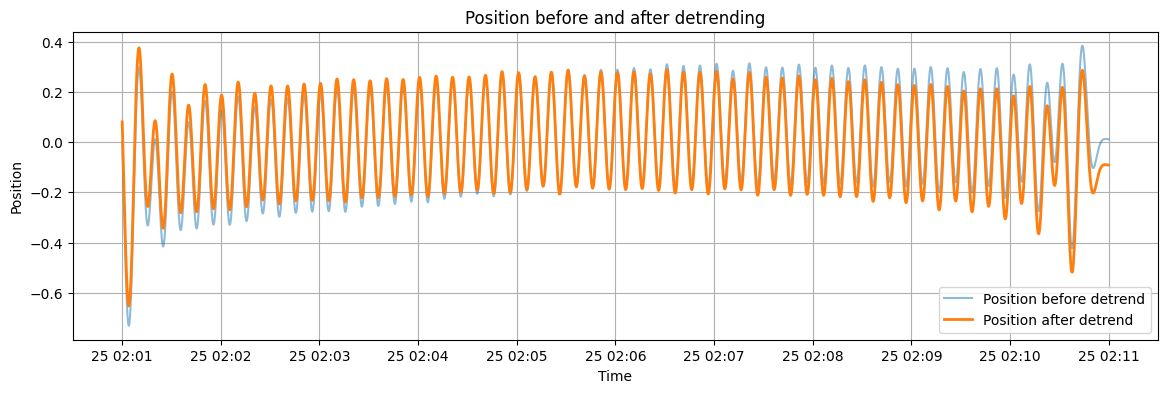

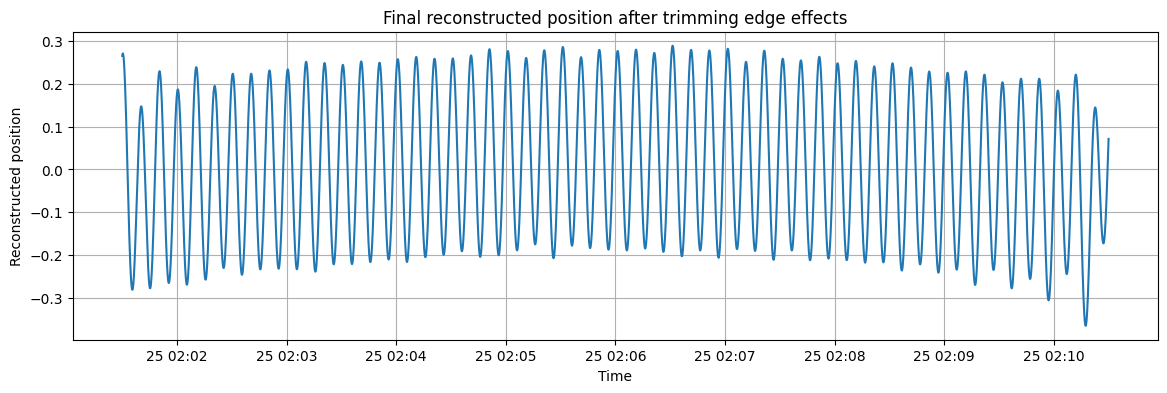

In [ ]:
# ============================================================
# QUESTION 6 - Position reconstruction from acceleration
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, detrend
from scipy.integrate import cumulative_trapezoid
# ------------------------------------------------------------
# 1. Select requested time window
# ------------------------------------------------------------
fs = 10.0
dt = 1 / fs
start_time = pd.to_datetime("2020-12-25T02:01:00")
end_time = pd.to_datetime("2020-12-25T02:11:00")
window_df = df[
   (df["Timestamp"] >= start_time) &
   (df["Timestamp"] <= end_time)
].copy()
t = window_df["Timestamp"]
a_raw = window_df["Acceleration"].values
print("Selected window:", window_df["Timestamp"].min(), "to", window_df["Timestamp"].max())
print("Number of samples:", len(window_df))
# ------------------------------------------------------------
# 2. Remove baseline
# ------------------------------------------------------------
baseline = np.mean(a_raw)
a_zero = a_raw - baseline
print("Baseline removed:", baseline)
# ------------------------------------------------------------
# 3. Band-pass filter around expected pump frequency
# ------------------------------------------------------------
lowcut = 0.05
highcut = 0.10
nyquist = fs / 2
b, a = butter(
   N=4,
   Wn=[lowcut / nyquist, highcut / nyquist],
   btype="band"
)
a_filtered = filtfilt(b, a, a_zero)
print("Band-pass filter:", lowcut, "-", highcut, "Hz")
# ------------------------------------------------------------
# 4. Integrate acceleration -> velocity and detrend
# ------------------------------------------------------------
velocity_raw = cumulative_trapezoid(a_filtered, dx=dt, initial=0)
velocity_detrended = detrend(velocity_raw)
# ------------------------------------------------------------
# 5. Integrate velocity -> position and detrend
# ------------------------------------------------------------
position_raw = cumulative_trapezoid(velocity_detrended, dx=dt, initial=0)
position_detrended = detrend(position_raw)
position_detrended = position_detrended - np.mean(position_detrended)
# ------------------------------------------------------------
# 6. Trim edge effects
# ------------------------------------------------------------
trim_seconds = 30
trim_samples = int(trim_seconds * fs)
plot_df = window_df.copy()
plot_df["acc_zero"] = a_zero
plot_df["acc_filtered"] = a_filtered
plot_df["velocity_raw"] = velocity_raw
plot_df["velocity_detrended"] = velocity_detrended
plot_df["position_raw"] = position_raw
plot_df["position"] = position_detrended
plot_trimmed = plot_df.iloc[trim_samples:-trim_samples].copy()
stroke_amplitude = plot_trimmed["position"].max() - plot_trimmed["position"].min()
print("Estimated stroke amplitude after trimming:", stroke_amplitude)
# ------------------------------------------------------------
# 7. Key plots
# ------------------------------------------------------------
# Acceleration preprocessing
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes[0].plot(t, a_raw)
axes[0].set_title("Raw acceleration")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Acceleration")
axes[0].grid(True)
axes[1].plot(t, a_zero, label="Zero-mean", alpha=0.5)
axes[1].plot(t, a_filtered, label="Filtered", linewidth=2)
axes[1].set_title("Zero-mean vs filtered acceleration")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Acceleration")
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()
# Velocity before/after detrending
plt.figure(figsize=(14, 4))
plt.plot(t, velocity_raw, label="Velocity before detrend", alpha=0.5)
plt.plot(t, velocity_detrended, label="Velocity after detrend", linewidth=2)
plt.title("Velocity before and after detrending")
plt.xlabel("Time")
plt.ylabel("Velocity")
plt.legend()
plt.grid(True)
plt.show()
# Position before/after detrending
plt.figure(figsize=(14, 4))
plt.plot(t, position_raw, label="Position before detrend", alpha=0.5)
plt.plot(t, position_detrended, label="Position after detrend", linewidth=2)
plt.title("Position before and after detrending")
plt.xlabel("Time")
plt.ylabel("Position")
plt.legend()
plt.grid(True)
plt.show()
# Final trimmed reconstructed position
plt.figure(figsize=(14, 4))
plt.plot(plot_trimmed["Timestamp"], plot_trimmed["position"])
plt.title("Final reconstructed position after trimming edge effects")
plt.xlabel("Time")
plt.ylabel("Reconstructed position")
plt.grid(True)
plt.show()

## Question 7 — Load vs Position Diagram
**Question:** Using the reconstructed position, plot load as a function of position for a couple minutes while the well is running. What is the physical significance of this phase diagram?
### Method
- Use reconstructed **position** (from Q6) and measured **load**  
- Select a **running time interval**  
- Plot: **Load vs Position**  
- This produces a **dynamometer card (phase diagram)**  
$$
F = F_{\text{rod}} + F_{\text{fluid}} + F_{\text{friction}}
$$
### Physical Significance
- **Upper branch:** upstroke → fluid is lifted → higher load  
- **Lower branch:** downstroke → lower load  
- **Side transitions:** stroke reversal → rapid load change  
- The closed loop represents **one pumping cycle**  
- Repeated similar loops indicate **stable pump operation**  
### Observation
- The plot shows **repeated loop-like cards** → cyclic motion  
- Shape is approximately **rectangular** → normal behavior  
- Small fluctuations and shifts observed:
  - may reflect real pump dynamics  
  - or reconstruction artifacts from acceleration integration  
### Key Insight
The dynamometer card provides a **compact representation of pump behavior**, linking mechanical motion (position) to load and allowing interpretation of operating conditions.

Q7 time window:
Start: 2020-12-25 02:01:30.065876124
End  : 2020-12-25 02:10:29.965876124
Number of running samples: 5400


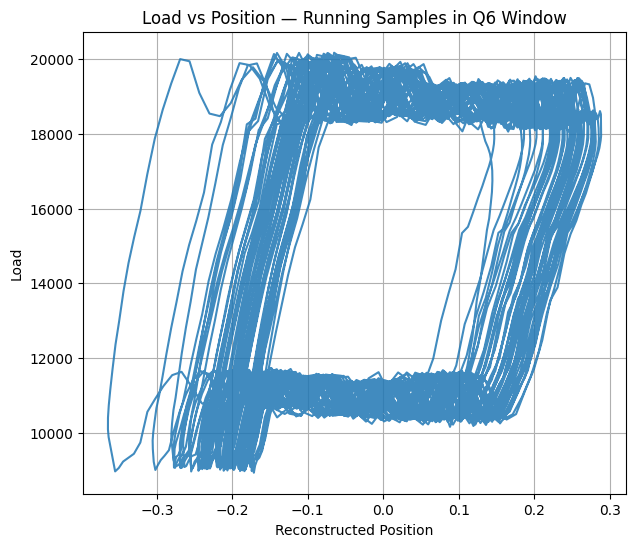

In [ ]:
# ============================================================
# QUESTION 7 - Load vs Position using SAME Q6 reconstructed window
# ============================================================
import matplotlib.pyplot as plt
# plot_trimmed already comes from 2020-12-25 02:01 to 02:11
# and already contains reconstructed position.
plot_trimmed = plot_trimmed.copy()
# Add Load from the same Q6 window, aligned after trimming
plot_trimmed["Load"] = window_df["Load"].iloc[trim_samples:-trim_samples].values
# Add running state from original df, aligned by index
plot_trimmed["is_running"] = df.loc[plot_trimmed.index, "is_running"].values
# Keep only running samples within the SAME reconstructed Q6 window
run_view = plot_trimmed[plot_trimmed["is_running"] == 1].copy()
print("Q7 time window:")
print("Start:", run_view["Timestamp"].min())
print("End  :", run_view["Timestamp"].max())
print("Number of running samples:", len(run_view))
# Plot Load vs Position for running samples in the Q6 window
plt.figure(figsize=(7, 6))
plt.plot(run_view["position"], run_view["Load"], alpha=0.85)
plt.title("Load vs Position — Running Samples in Q6 Window")
plt.xlabel("Reconstructed Position")
plt.ylabel("Load")
plt.grid(True)
plt.show()

## Question 8 — Effect of Liquid/Gas Ratio and Mechanical Failures
### 1. Does the liquid/gas ratio affect the pump card?
Yes.
- **High liquid fraction (good fillage):**
  - Larger, more rectangular card
  - Higher load and larger area
  - Efficient fluid lifting
- **High gas fraction (gas interference):**
  - Smaller card area
  - Distorted shape
  - Reduced load due to gas compressibility
### 2. Effect of mechanical failures
Mechanical issues modify the card shape:
- **Valve leakage / wear:** Rounded or distorted transitions  
- **Tubing leak:** Reduced load and smaller area  
- **Friction (rod/tubing contact):** Asymmetry in the loop  
- **Blockage / paraffin:** Increased resistance and abnormal load behavior  
### 3. Shape and regimes interpretation
- Most cards are **approximately rectangular** → normal operation  
- Observed deviations:
    - **Waves (upper branch):** upstroke instability → fluid/gas interaction or valve dynamics  
    - **Waves (lower branch):** downstroke instability → gas compressibility or flow effects  
    - **Left-side drop:** delayed load transfer → valve delay, leakage, or friction  
    - **Cycle shift:** changing conditions → fillage variation, load change, or reconstruction drift

Pump-card shape directly reflects **downhole conditions**, and deviations from the ideal rectangle indicate **changes in fluid behavior or mechanical performance**.

## Question 9 — Identifying Downhole Operating Conditions
**Question:** Can we identify different types of downhole operating conditions, such as changes in pump fillage or mechanical conditions? What class of problems and algorithms can be leveraged to automate this?
### Method
I treat each pump cycle, or dynamometer card, as one observation. Each card is converted into a feature vector that describes its physical and geometric behavior.
The features used are:
- **card_area:** approximate area enclosed by the load-position card. It is related to work performed during one cycle.
- **load_range:** difference between maximum and minimum load. It reflects load variation during the stroke.
- **position_range:** reconstructed stroke range.
- **duration_sec:** duration of one pumping cycle.
- **top_wave_std:** fluctuation on the upper branch of the card.
- **bottom_wave_std:** fluctuation on the lower branch of the card.
- **left_drop / right_drop:** load variation near the left and right side transitions.
- **transition_asymmetry:** difference between left and right transition behavior.
- **branch_asymmetry:** difference between the first and second half of the cycle.


Since no expert labels are provided, this is an **unsupervised regime-discovery problem**. I use K-Means clustering to group pump cards with similar behavior. The clusters are interpreted as possible operating-regime hypotheses, not confirmed failure labels.
Possible physical regimes include:
- stable/normal pumping,
- low pump fillage,
- gas interference,
- valve or fluid-dynamic irregularity,
- transient or reconstruction/artifact behavior.
Final physical interpretation would require domain expert validation.


Number of running segments: 255
Total pump cards extracted: 18594


,cycle_id,segment_id,start_time,end_time,card_area,load_range,position_range,duration_sec,top_wave_std,bottom_wave_std,left_drop,right_drop,transition_asymmetry,branch_asymmetry
0,0,2,2020-12-25 00:00:38.465876124,2020-12-25 00:00:48.365876124,3813.740307,10765.527187,0.575902,9.9,389.052829,585.783981,3013.269640,2369.856890,643.412750,4486.108988
1,1,2,2020-12-25 00:00:48.465876124,2020-12-25 00:00:58.465876124,2353.742231,10845.970352,0.534874,10.0,414.298252,618.615418,1615.420641,1338.330006,277.090635,4385.985457
2,2,2,2020-12-25 00:00:58.565876124,2020-12-25 00:01:08.565876124,3527.351317,10813.915581,0.544304,10.0,396.592694,617.880480,2697.690552,2804.918688,107.228136,4665.623969
3,3,2,2020-12-25 00:01:08.665876124,2020-12-25 00:01:18.465876124,2759.253998,10977.799670,0.443406,9.8,403.318913,602.061223,1640.291494,2195.085918,554.794424,4694.566112
4,4,2,2020-12-25 00:01:18.565876124,2020-12-25 00:01:28.465876124,2882.793778,11164.974240,0.463012,9.9,455.974681,609.059958,1521.515336,1697.825136,176.309800,4463.359529


,k,inertia,silhouette,DBI,silhouette_rank,DBI_rank,combined_rank
0,2,125645.0883,0.5338,0.8489,2.0,2.0,4.0
1,3,101463.9155,0.5513,0.6806,1.0,1.0,2.0
2,4,80555.8276,0.3186,0.9863,3.0,3.0,6.0
3,5,68517.1928,0.2688,1.0442,6.0,4.0,10.0
4,6,60886.1756,0.2710,1.0973,5.0,6.0,11.0
5,7,56399.4640,0.2740,1.0499,4.0,5.0,9.0


Selected K-Means k: 3


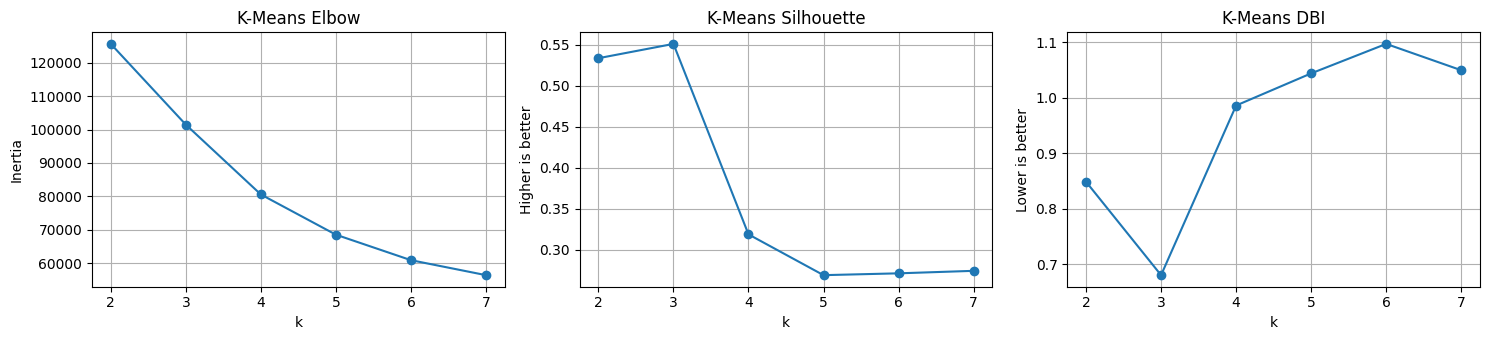

,k,silhouette,DBI,silhouette_rank,DBI_rank,combined_rank
0,2,0.5307,0.8339,2.0,2.0,4.0
1,3,0.5481,0.6591,1.0,1.0,2.0
2,4,0.3015,1.0167,3.0,3.0,6.0
3,5,0.2320,1.0886,4.0,4.0,8.0
4,6,0.2202,1.1872,5.0,5.0,10.0
5,7,0.2176,1.2904,6.0,6.0,12.0


Selected Hierarchical k: 3


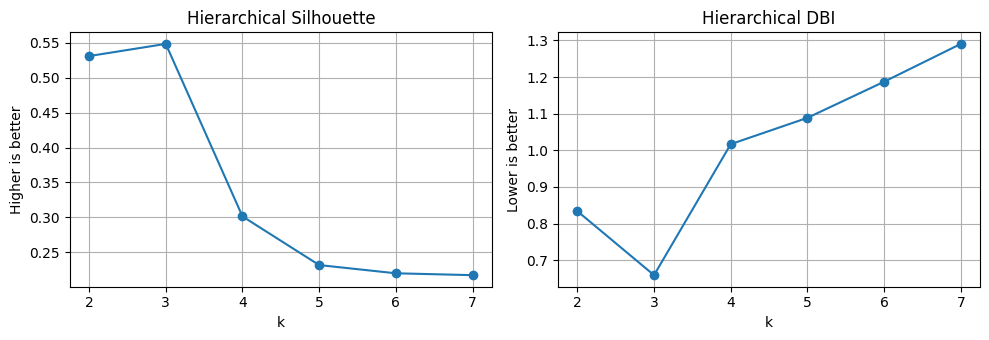

,Method,Selected k / labels,Cluster counts
0,K-Means,3,"{0: 162, 1: 2110, 2: 16322}"
1,Hierarchical,3,"{0: 16398, 1: 2044, 2: 152}"


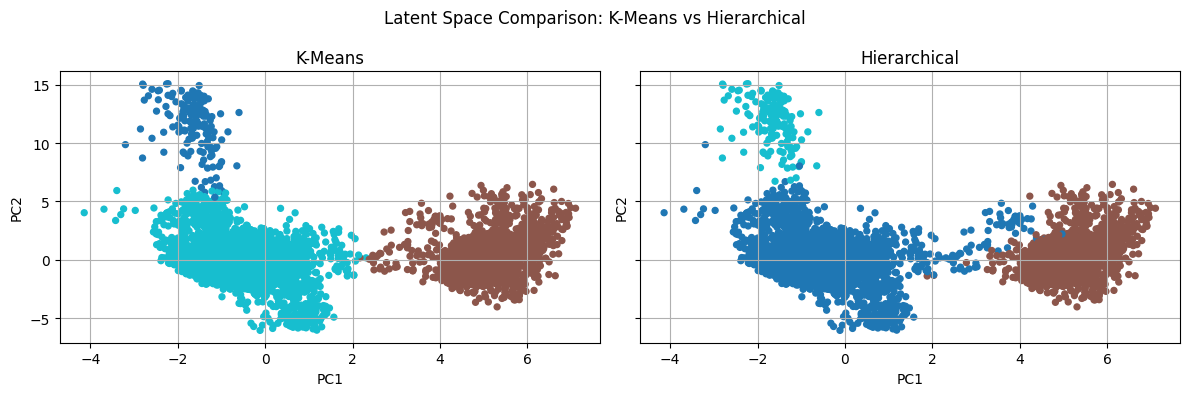

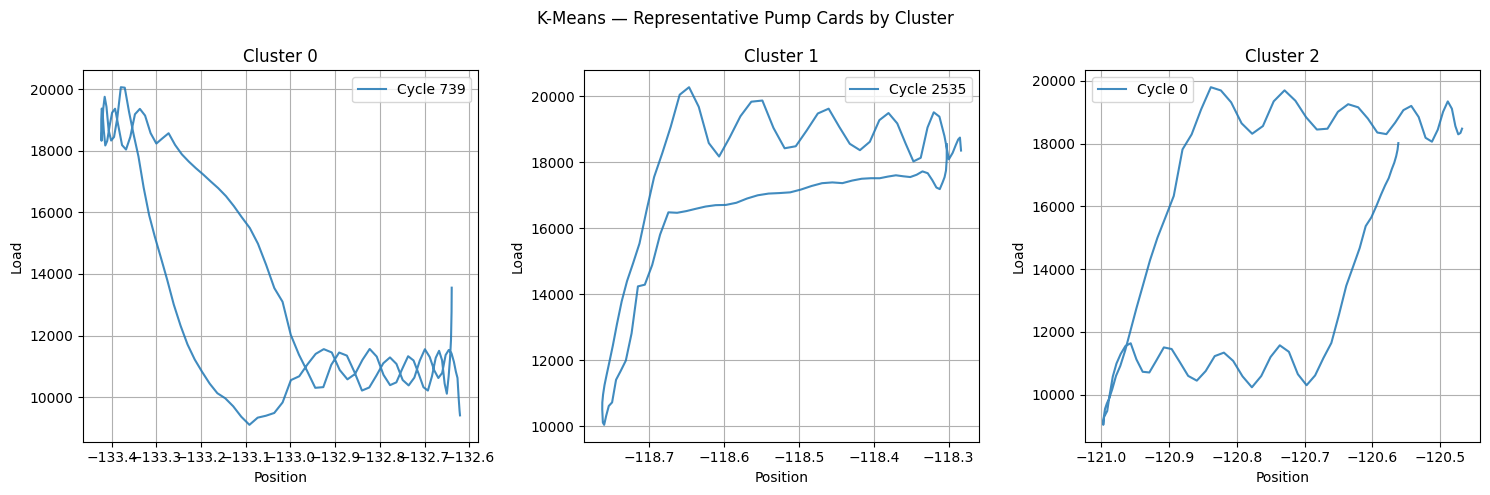

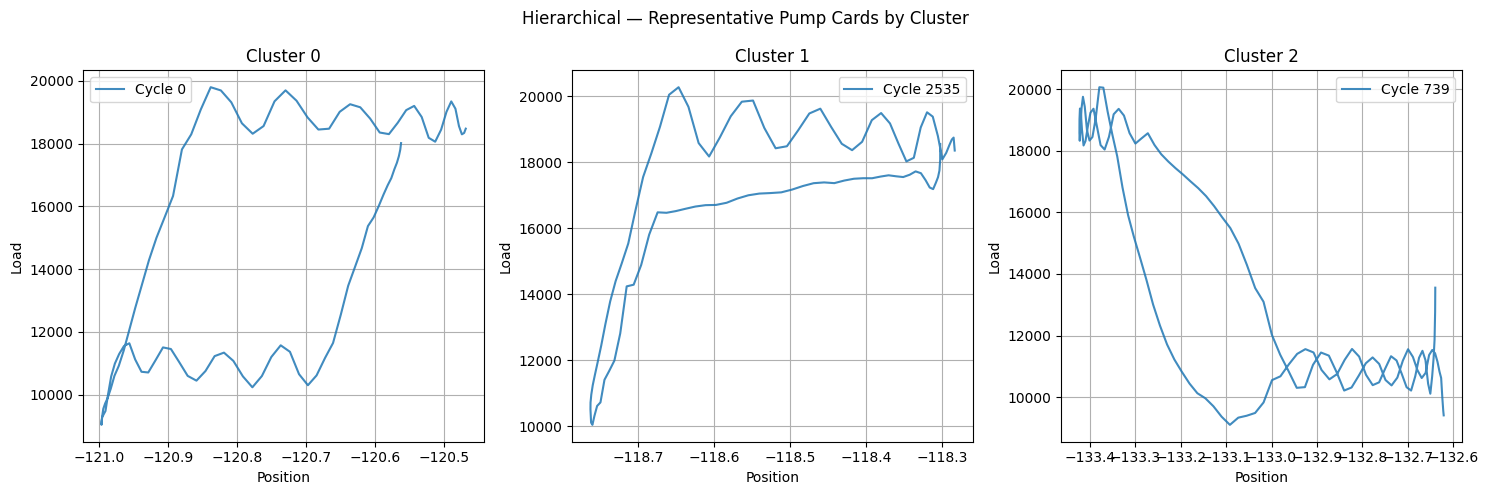

,method,cluster,card_area,load_range,position_range,duration_sec,top_wave_std,bottom_wave_std,left_drop,right_drop,transition_asymmetry,branch_asymmetry
0,K-Means,0,5462.74 ± 566.31,9747.58 ± 235.19,0.92 ± 0.09,11.44 ± 0.27,314.92 ± 61.17,340.05 ± 33.65,3513.32 ± 512.66,1701.33 ± 302.57,1843.66 ± 510.82,4061.58 ± 283.05
1,K-Means,1,1190.18 ± 190.31,9305.21 ± 302.68,0.47 ± 0.05,9.89 ± 0.23,276.36 ± 35.36,1262.74 ± 154.12,2450.18 ± 596.0,1579.33 ± 474.09,909.02 ± 795.56,2296.86 ± 242.41
2,K-Means,2,3151.17 ± 244.12,9957.14 ± 377.31,0.48 ± 0.03,9.93 ± 0.17,360.76 ± 84.9,332.01 ± 69.39,2158.61 ± 437.53,1972.94 ± 435.14,354.74 ± 280.5,5152.67 ± 265.36
3,Hierarchical,0,3145.35 ± 267.75,9954.97 ± 378.67,0.48 ± 0.03,9.93 ± 0.17,360.39 ± 84.93,334.73 ± 85.3,2159.33 ± 439.57,1971.83 ± 435.72,357.33 ± 286.4,5143.36 ± 300.9
4,Hierarchical,1,1179.64 ± 167.61,9301.48 ± 300.79,0.46 ± 0.04,9.88 ± 0.21,276.55 ± 35.63,1270.95 ± 131.1,2458.53 ± 591.97,1575.6 ± 473.77,909.9 ± 797.47,2275.94 ± 204.66
5,Hierarchical,2,5533.55 ± 508.82,9734.93 ± 218.83,0.94 ± 0.07,11.47 ± 0.24,312.44 ± 59.48,340.85 ± 30.54,3538.82 ± 481.27,1681.62 ± 266.18,1890.95 ± 484.27,4034.67 ± 264.1


In [ ]:
# ============================================================
# QUESTION 9 - Reconstruct position per running segment
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, detrend, find_peaks
from scipy.integrate import cumulative_trapezoid
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
# ------------------------------------------------------------
# 1. Clean full data
# ------------------------------------------------------------
q9_full = df[["Timestamp", "Acceleration", "Load", "is_running"]].copy()
q9_full["Acceleration"] = (
   q9_full["Acceleration"]
   .replace([np.inf, -np.inf], np.nan)
   .interpolate(limit_direction="both")
)
q9_full["Load"] = (
   q9_full["Load"]
   .replace([np.inf, -np.inf], np.nan)
   .interpolate(limit_direction="both")
)
# ------------------------------------------------------------
# 2. Split into continuous ON/OFF segments
# ------------------------------------------------------------
q9_full["segment_id"] = (q9_full["is_running"].diff() != 0).cumsum()
running_segments = q9_full[q9_full["is_running"] == 1].groupby("segment_id")
print("Number of running segments:", len(running_segments))
# ------------------------------------------------------------
# 3. Filter setup
# ------------------------------------------------------------
fs = 10.0
dt = 1 / fs
lowcut = 0.05
highcut = 0.10
nyquist = fs / 2
b, a = butter(
   N=4,
   Wn=[lowcut / nyquist, highcut / nyquist],
   btype="band"
)
trim_seconds = 20
trim_samples = int(trim_seconds * fs)
# ------------------------------------------------------------
# 4. Robust pump-card area
# ------------------------------------------------------------
def pump_card_area(position, load):
   x = np.asarray(position)
   y = np.asarray(load)
   x_closed = np.r_[x, x[0]]
   y_closed = np.r_[y, y[0]]
   return 0.5 * np.abs(
       np.sum(x_closed[:-1] * y_closed[1:] - x_closed[1:] * y_closed[:-1])
   )
# ------------------------------------------------------------
# 5. Reconstruct position inside each running segment
#    and extract pump-card features
# ------------------------------------------------------------
records = []
global_cycle_id = 0
for seg_id, seg in running_segments:
   seg = seg.copy()
   # Need enough samples for filtering, trimming, and at least a few cycles
   if len(seg) < int(60 * fs):
       continue
   a_raw = seg["Acceleration"].values
   a_zero = a_raw - np.mean(a_raw)
   try:
       a_filtered = filtfilt(b, a, a_zero)
       velocity = cumulative_trapezoid(a_filtered, dx=dt, initial=0)
       velocity = detrend(velocity)
       position = cumulative_trapezoid(velocity, dx=dt, initial=0)
       position = detrend(position)
       position = position - np.mean(position)
   except Exception as e:
       print(f"Skipping segment {seg_id} due to reconstruction error:", e)
       continue
   seg["position"] = position
   # Trim only this running segment to remove local edge effects
   seg_trimmed = seg.iloc[trim_samples:-trim_samples].copy()
   if len(seg_trimmed) < int(30 * fs):
       continue
   pos = seg_trimmed["position"].values
   peaks, _ = find_peaks(pos, distance=int(8 * fs))
   if len(peaks) < 2:
       continue
   for i in range(len(peaks) - 1):
       s, e = peaks[i], peaks[i + 1]
       cycle = seg_trimmed.iloc[s:e].copy()
       if len(cycle) < 30:
           continue
       p = cycle["position"].values
       l = cycle["Load"].values
       t = cycle["Timestamp"]
       card_area = pump_card_area(p, l)
       load_range = l.max() - l.min()
       position_range = p.max() - p.min()
       duration_sec = (t.iloc[-1] - t.iloc[0]).total_seconds()
       top_load = l[l >= np.percentile(l, 75)]
       bottom_load = l[l <= np.percentile(l, 25)]
       top_wave_std = np.std(top_load)
       bottom_wave_std = np.std(bottom_load)
       left_load = l[p <= np.percentile(p, 10)]
       right_load = l[p >= np.percentile(p, 90)]
       left_drop = left_load.max() - left_load.min() if len(left_load) > 2 else 0
       right_drop = right_load.max() - right_load.min() if len(right_load) > 2 else 0
       transition_asymmetry = abs(left_drop - right_drop)
       mid = len(l) // 2
       branch_asymmetry = abs(l[:mid].mean() - l[mid:].mean())
       records.append({
           "cycle_id": global_cycle_id,
           "segment_id": seg_id,
           "start_time": t.iloc[0],
           "end_time": t.iloc[-1],
           "card_area": card_area,
           "load_range": load_range,
           "position_range": position_range,
           "duration_sec": duration_sec,
           "top_wave_std": top_wave_std,
           "bottom_wave_std": bottom_wave_std,
           "left_drop": left_drop,
           "right_drop": right_drop,
           "transition_asymmetry": transition_asymmetry,
           "branch_asymmetry": branch_asymmetry
       })
       global_cycle_id += 1
q9_features = pd.DataFrame(records)
print("Total pump cards extracted:", len(q9_features))
display(q9_features.head())
# ------------------------------------------------------------
# 7. Prepare feature matrix
# ------------------------------------------------------------
feature_cols = [
   "card_area",
   "load_range",
   "position_range",
   "duration_sec",
   "top_wave_std",
   "bottom_wave_std",
   "left_drop",
   "right_drop",
   "transition_asymmetry",
   "branch_asymmetry"
]
X = q9_features[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# ------------------------------------------------------------
# 8. K-Means: choose k using elbow, silhouette, and DBI
# ------------------------------------------------------------
k_values = range(2, 8)
sample_size = min(3000, len(X_scaled))
kmeans_inertias = []
kmeans_silhouettes = []
kmeans_dbi = []
for k in k_values:
   km = KMeans(n_clusters=k, random_state=0, n_init=10)
   labels = km.fit_predict(X_scaled)
   kmeans_inertias.append(km.inertia_)
   kmeans_silhouettes.append(
       silhouette_score(X_scaled, labels, sample_size=sample_size, random_state=0)
   )
   kmeans_dbi.append(davies_bouldin_score(X_scaled, labels))
kmeans_scores = pd.DataFrame({
   "k": list(k_values),
   "inertia": kmeans_inertias,
   "silhouette": kmeans_silhouettes,
   "DBI": kmeans_dbi
})
kmeans_scores["silhouette_rank"] = kmeans_scores["silhouette"].rank(ascending=False)
kmeans_scores["DBI_rank"] = kmeans_scores["DBI"].rank(ascending=True)
kmeans_scores["combined_rank"] = kmeans_scores["silhouette_rank"] + kmeans_scores["DBI_rank"]
display(kmeans_scores.round(4))
best_k_kmeans = int(kmeans_scores.sort_values("combined_rank").iloc[0]["k"])
print("Selected K-Means k:", best_k_kmeans)
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
axes[0].plot(kmeans_scores["k"], kmeans_scores["inertia"], marker="o")
axes[0].set_title("K-Means Elbow")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].grid(True)
axes[1].plot(kmeans_scores["k"], kmeans_scores["silhouette"], marker="o")
axes[1].set_title("K-Means Silhouette")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Higher is better")
axes[1].grid(True)
axes[2].plot(kmeans_scores["k"], kmeans_scores["DBI"], marker="o")
axes[2].set_title("K-Means DBI")
axes[2].set_xlabel("k")
axes[2].set_ylabel("Lower is better")
axes[2].grid(True)
plt.tight_layout()
plt.show()
kmeans = KMeans(n_clusters=best_k_kmeans, random_state=0, n_init=10)
q9_features["regime_kmeans"] = kmeans.fit_predict(X_scaled)

# ------------------------------------------------------------
# 9. Hierarchical clustering: choose k using silhouette and DBI
# ------------------------------------------------------------
hier_silhouettes = []
hier_dbi = []
for k in k_values:
   hier = AgglomerativeClustering(n_clusters=k, linkage="ward")
   labels = hier.fit_predict(X_scaled)
   hier_silhouettes.append(
       silhouette_score(X_scaled, labels, sample_size=sample_size, random_state=0)
   )
   hier_dbi.append(davies_bouldin_score(X_scaled, labels))
hier_scores = pd.DataFrame({
   "k": list(k_values),
   "silhouette": hier_silhouettes,
   "DBI": hier_dbi
})
hier_scores["silhouette_rank"] = hier_scores["silhouette"].rank(ascending=False)
hier_scores["DBI_rank"] = hier_scores["DBI"].rank(ascending=True)
hier_scores["combined_rank"] = hier_scores["silhouette_rank"] + hier_scores["DBI_rank"]
display(hier_scores.round(4))
best_k_hier = int(hier_scores.sort_values("combined_rank").iloc[0]["k"])
print("Selected Hierarchical k:", best_k_hier)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(hier_scores["k"], hier_scores["silhouette"], marker="o")
axes[0].set_title("Hierarchical Silhouette")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Higher is better")
axes[0].grid(True)
axes[1].plot(hier_scores["k"], hier_scores["DBI"], marker="o")
axes[1].set_title("Hierarchical DBI")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Lower is better")
axes[1].grid(True)
plt.tight_layout()
plt.show()
hier = AgglomerativeClustering(n_clusters=best_k_hier, linkage="ward")
q9_features["regime_hierarchical"] = hier.fit_predict(X_scaled)


# ------------------------------------------------------------
# 10. Summary table: cluster counts
# ------------------------------------------------------------
methods = {
   "K-Means": "regime_kmeans",
   "Hierarchical": "regime_hierarchical"
}
summary_rows = []
for method_name, col in methods.items():
   counts = q9_features[col].value_counts().sort_index()
   summary_rows.append({
       "Method": method_name,
       "Selected k / labels": q9_features[col].nunique(),
       "Cluster counts": dict(counts)
   })
cluster_summary = pd.DataFrame(summary_rows)
display(cluster_summary)


# ------------------------------------------------------------
# 11. PCA latent-space visualization side by side
# ------------------------------------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
q9_features["PC1"] = X_pca[:, 0]
q9_features["PC2"] = X_pca[:, 1]
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
for ax, (method_name, col) in zip(axes, methods.items()):
   ax.scatter(
       q9_features["PC1"],
       q9_features["PC2"],
       c=q9_features[col],
       cmap="tab10",
       s=18
   )
   ax.set_title(method_name)
   ax.set_xlabel("PC1")
   ax.set_ylabel("PC2")
   ax.grid(True)
plt.suptitle("Latent Space Comparison: K-Means vs Hierarchical")
plt.tight_layout()
plt.show()




# ============================================================
# Representative pump cards for each cluster
# Clusters shown side by side for each method
# Each subplot keeps its own axis scale
# ============================================================
methods = {
   "K-Means": "regime_kmeans",
   "Hierarchical": "regime_hierarchical"
}
for method_name, regime_col in methods.items():
   regimes = sorted(q9_features[regime_col].unique())
   n_clusters = len(regimes)
   fig, axes = plt.subplots(
       1, n_clusters,
       figsize=(5 * n_clusters, 5),
       sharex=False,
       sharey=False
   )
   if n_clusters == 1:
       axes = [axes]
   for ax, regime in zip(axes, regimes):
       example = q9_features[q9_features[regime_col] == regime].head(1)
       for _, row in example.iterrows():
           cycle = q9_df[
               (q9_df["Timestamp"] >= row["start_time"]) &
               (q9_df["Timestamp"] <= row["end_time"])
           ]
           ax.plot(
               cycle["position"],
               cycle["Load"],
               alpha=0.85,
               label=f"Cycle {int(row['cycle_id'])}"
           )
       ax.set_title(f"Cluster {regime}")
       ax.set_xlabel("Position")
       ax.set_ylabel("Load")
       ax.legend()
       ax.grid(True)
   plt.suptitle(f"{method_name} — Representative Pump Cards by Cluster")
   plt.tight_layout()
   plt.show()


# ============================================================
# Mean ± standard deviation of features by method and cluster
# ============================================================
summary_tables = []
for method_name, regime_col in methods.items():
   grouped_mean = (
       q9_features
       .groupby(regime_col)[feature_cols]
       .mean()
       .round(2)
   )
   grouped_std = (
       q9_features
       .groupby(regime_col)[feature_cols]
       .std()
       .round(2)
   )
   combined = grouped_mean.astype(str) + " ± " + grouped_std.astype(str)
   combined = combined.reset_index()
   combined = combined.rename(columns={regime_col: "cluster"})
   combined.insert(0, "method", method_name)
   summary_tables.append(combined)
feature_summary_table = pd.concat(summary_tables, ignore_index=True)
display(feature_summary_table)



## Question 10 — Time Structure and Regularities of Regimes
**Question:** Can we investigate the possible regularities and time structure of the different regimes? Can we offer hypotheses regarding the changes they illustrate in downhole conditions?
### Method
To investigate the temporal structure of the identified regimes, I analyze how pump behavior evolves over time using the extracted features and clustering results.
This includes:
- plotting **card area over time**, colored by regime,
- plotting **regime labels over time** to observe transitions,
- comparing **multiple clustering methods (K-Means and Hierarchical)** side by side,
- analyzing the **full dataset** to capture long-term behavior,
- applying a **zoomed time window** (e.g., 12 hours) to inspect local patterns and transitions,
- visually identifying **repeated patterns and regime ordering within running periods**.

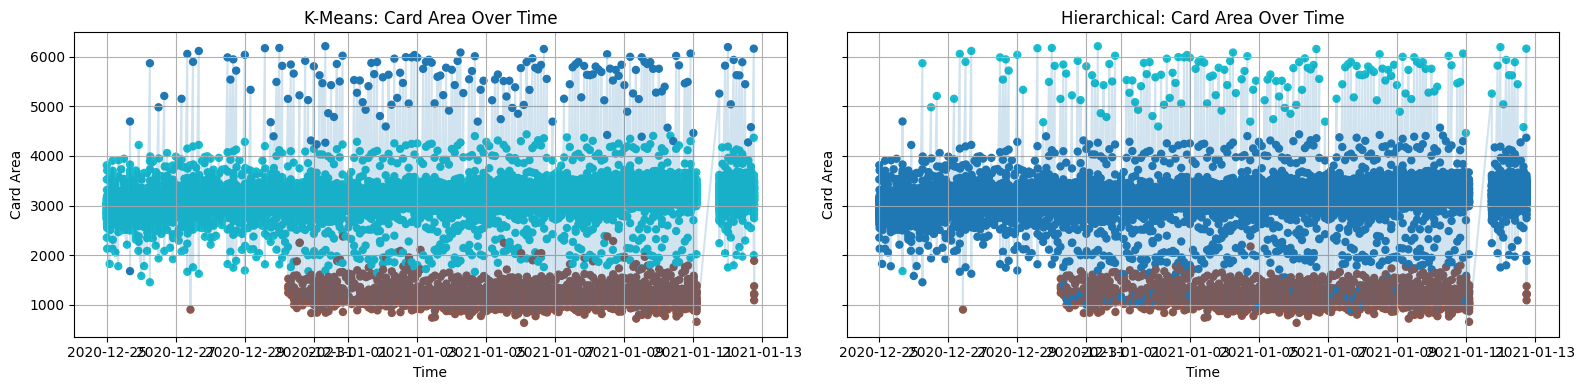

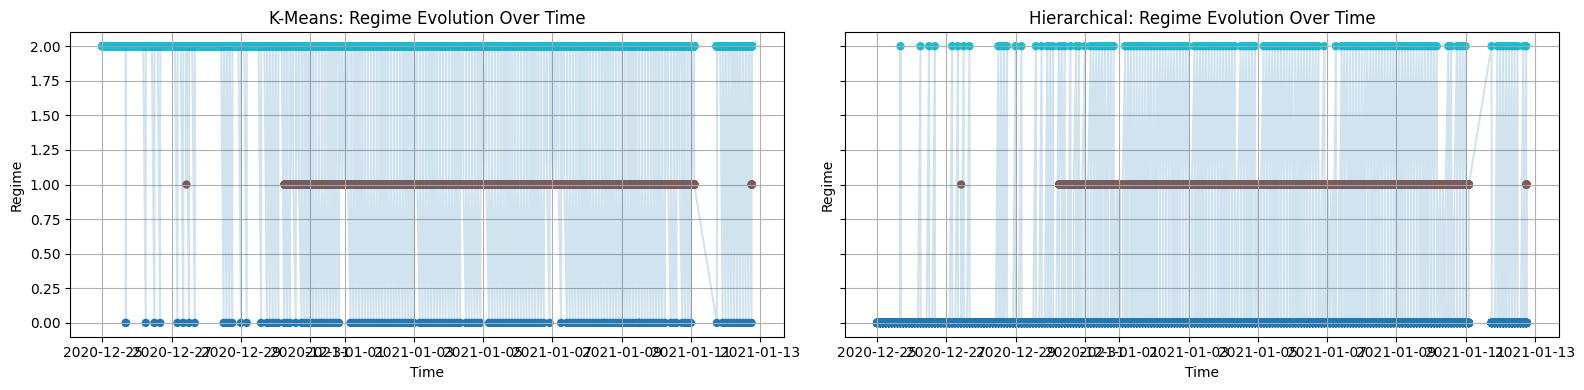

Requested zoom window:
Start: 2021-01-03 00:00:00
End  : 2021-01-03 12:00:00
Number of pump cards: 511


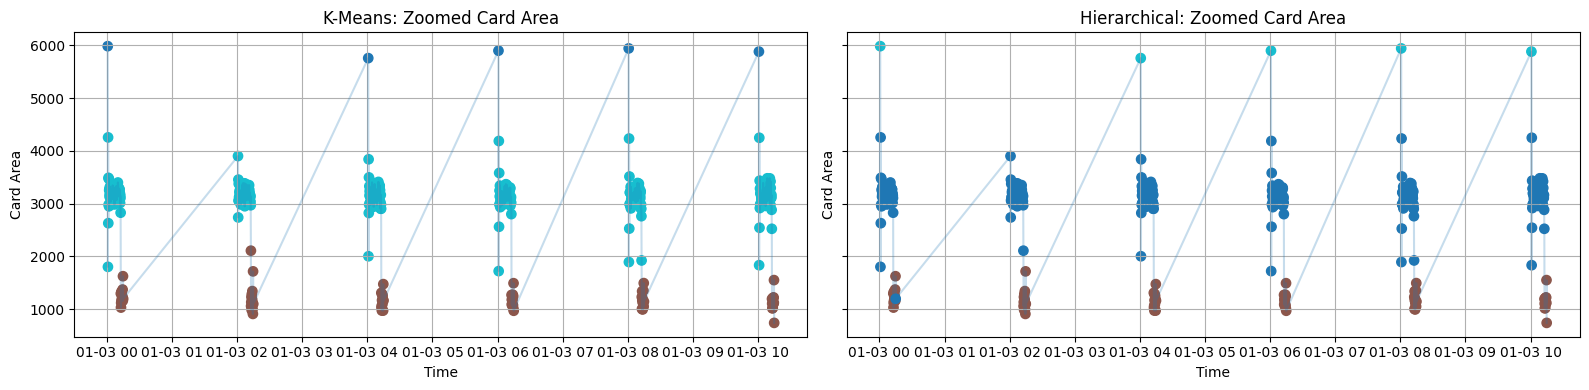

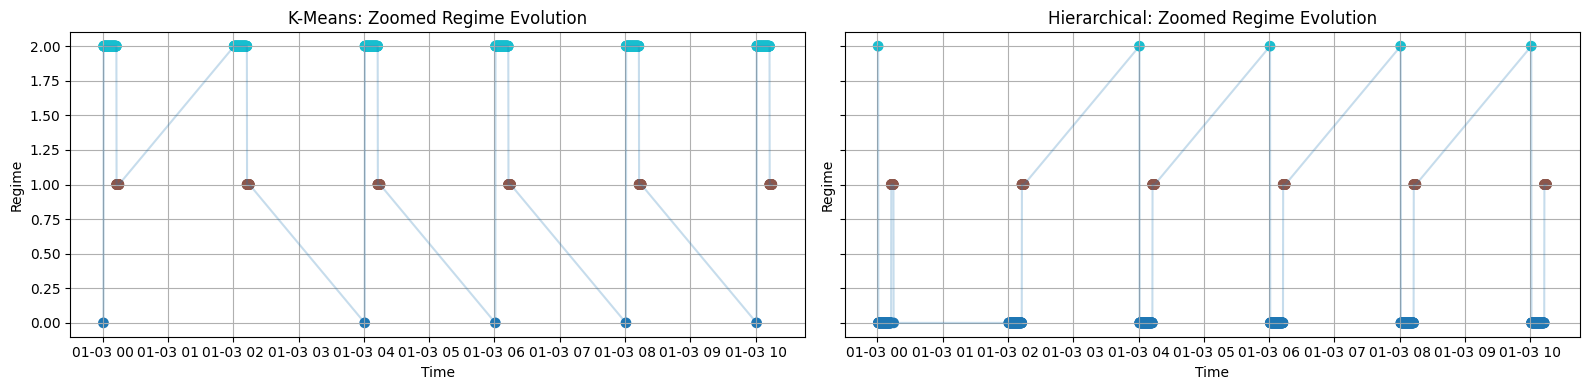

,Method,Full dataset regime counts,Zoom window regime counts
0,K-Means,"{0: 162, 1: 2110, 2: 16322}","{0: 5, 1: 80, 2: 426}"
1,Hierarchical,"{0: 16398, 1: 2044, 2: 152}","{0: 428, 1: 78, 2: 5}"


In [ ]:
# ============================================================
# QUESTION 10 - Regime evolution over time
# K-Means vs Hierarchical
# ============================================================
import matplotlib.pyplot as plt
import pandas as pd
methods = {
   "K-Means": "regime_kmeans",
   "Hierarchical": "regime_hierarchical"
}
# ------------------------------------------------------------
# 1. Full-time card area colored by regime
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=True)
for ax, (method_name, regime_col) in zip(axes, methods.items()):
   ax.scatter(
       q9_features["start_time"],
       q9_features["card_area"],
       c=q9_features[regime_col],
       cmap="tab10",
       s=25
   )
   ax.plot(q9_features["start_time"], q9_features["card_area"], alpha=0.2)
   ax.set_title(f"{method_name}: Card Area Over Time")
   ax.set_xlabel("Time")
   ax.set_ylabel("Card Area")
   ax.grid(True)
plt.tight_layout()
plt.show()
# ------------------------------------------------------------
# 2. Full-time regime evolution
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=True)
for ax, (method_name, regime_col) in zip(axes, methods.items()):
   ax.scatter(
       q9_features["start_time"],
       q9_features[regime_col],
       c=q9_features[regime_col],
       cmap="tab10",
       s=25
   )
   ax.plot(q9_features["start_time"], q9_features[regime_col], alpha=0.2)
   ax.set_title(f"{method_name}: Regime Evolution Over Time")
   ax.set_xlabel("Time")
   ax.set_ylabel("Regime")
   ax.grid(True)
plt.tight_layout()
plt.show()
# ------------------------------------------------------------
# 3. Zoomed time window: Jan 3 for 12 hours
# ------------------------------------------------------------
zoom_start = pd.to_datetime("2021-01-03 00:00:00")
zoom_duration = pd.Timedelta(hours=12)
zoom_end = zoom_start + zoom_duration
zoom_df = q9_features[
   (q9_features["start_time"] >= zoom_start) &
   (q9_features["start_time"] <= zoom_end)
].copy()
print("Requested zoom window:")
print("Start:", zoom_start)
print("End  :", zoom_end)
print("Number of pump cards:", len(zoom_df))
if len(zoom_df) == 0:
   zoom_start = q9_features["start_time"].min()
   zoom_end = zoom_start + zoom_duration
   zoom_df = q9_features[
       (q9_features["start_time"] >= zoom_start) &
       (q9_features["start_time"] <= zoom_end)
   ].copy()
   print("\nNo data found in requested window.")
   print("Using first available 12-hour window instead:")
   print("Start:", zoom_start)
   print("End  :", zoom_end)
   print("Number of pump cards:", len(zoom_df))
# ------------------------------------------------------------
# 4. Zoomed card area colored by regime
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=True)
for ax, (method_name, regime_col) in zip(axes, methods.items()):
   ax.scatter(
       zoom_df["start_time"],
       zoom_df["card_area"],
       c=zoom_df[regime_col],
       cmap="tab10",
       s=45
   )
   ax.plot(zoom_df["start_time"], zoom_df["card_area"], alpha=0.25)
   ax.set_title(f"{method_name}: Zoomed Card Area")
   ax.set_xlabel("Time")
   ax.set_ylabel("Card Area")
   ax.grid(True)
plt.tight_layout()
plt.show()
# ------------------------------------------------------------
# 5. Zoomed regime evolution
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=True)
for ax, (method_name, regime_col) in zip(axes, methods.items()):
   ax.scatter(
       zoom_df["start_time"],
       zoom_df[regime_col],
       c=zoom_df[regime_col],
       cmap="tab10",
       s=45
   )
   ax.plot(zoom_df["start_time"], zoom_df[regime_col], alpha=0.25)
   ax.set_title(f"{method_name}: Zoomed Regime Evolution")
   ax.set_xlabel("Time")
   ax.set_ylabel("Regime")
   ax.grid(True)
plt.tight_layout()
plt.show()
# ------------------------------------------------------------
# 6. Temporal summary tables
# ------------------------------------------------------------
summary_rows = []
for method_name, regime_col in methods.items():
   full_counts = q9_features[regime_col].value_counts().sort_index().to_dict()
   zoom_counts = zoom_df[regime_col].value_counts().sort_index().to_dict()
   summary_rows.append({
       "Method": method_name,
       "Full dataset regime counts": full_counts,
       "Zoom window regime counts": zoom_counts
   })
temporal_summary = pd.DataFrame(summary_rows)
display(temporal_summary)

### 🔹 1. Startup Transient (Beginning of Running Period)
- Few **irregular pump cards**
- Non-rectangular, distorted shapes  
- **Cause:** pump not stabilized yet  
- → fluid not fully lifted / gas presence / valve delay  
### 🔹 2. Steady-State Operation (Middle)
- **Stable rectangular cards**
- Consistent card area and shape  
- **Normal pumping behavior**  
- → fluid flow and load fully stabilized  
### 🔹 3. Shutdown / Transition Phase (End)
- Slight **shape degradation**
- Distortion mainly on **bottom/right side**  
- **Cause:** changing flow conditions  
- → load drop / fluid redistribution / gas effects  
---
###  Key Insight
> Regimes are not random — they follow a repeatable lifecycle:  
> **startup → stable → shutdown**

###  Takeaway
Clustering reveals the **dynamic behavior of the pump over time**, not just static regimes.